In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

In [61]:
# Lista com os caminhos dos seus bancos de dados (ajuste se tiver mais)
DATABASES = [
    "../data/dataset_artigo.db",
    #"../data/dataset_informacional.db",
    #"../data/dataset_social.db",
    #"../data/dataset.db",
    #"../data/dataset_livro.db",
    #"../data/dataset_literariro_autores.db",
    #"../data/dataset_literariro.db", # Coloque o nome exato que está na sua pasta
]

def carregar_dados(db_paths):
    dataframes = []
    
    for path in db_paths:
        if os.path.exists(path):
            try:
                # Conecta ao banco
                conn = sqlite3.connect(path)
                
                # Lê a tabela inteira para o Pandas
                df = pd.read_sql_query("SELECT * FROM texts", conn)
                
                # Adiciona uma coluna com o nome do arquivo para rastreio
                df['origem_db'] = os.path.basename(path)
                
                dataframes.append(df)
                conn.close()
                print(f"[OK] {os.path.basename(path)}: {len(df)} textos carregados.")
            except Exception as e:
                print(f"[ERRO] Falha ao ler {path}: {e}")
        else:
            print(f"[AVISO] Ficheiro não encontrado: {path}")
            
    # Une todos os dataframes num só (Empilhamento)
    if dataframes:
        df_completo = pd.concat(dataframes, ignore_index=True)
        print(f"\n[SUCESSO] Dataset unificado criado com {len(df_completo)} textos no total!")
        return df_completo
    else:
        return pd.DataFrame()

# Executa a função
df = carregar_dados(DATABASES)

# Mostra as primeiras 5 linhas para confirmar que deu certo
display(df.head())

[OK] dataset_artigo.db: 6458 textos carregados.

[SUCESSO] Dataset unificado criado com 6458 textos no total!


,text_id,content,label,broad_area,specific_theme,char_count,word_count,size_category,creation_date,source_url,source_name,content_hash,origem_db
0,e446c446-4115-42d9-a794-637ea5f225a3,A História é a ciência dos homens no tempo. Es...,0,Acadêmica,Others,5696,863,Longo,2016,https://www.scielo.br/article/S0104-8775201600...,scielo.br,5ec5f75850bf655c83236c10b38bd295,dataset_artigo.db
1,8b296347-bb97-400f-8a9e-a99bb0d1a49d,"Apresentamos, nesta nossa publicação, três tex...",0,Acadêmica,Others,8072,1221,Longo,2016,https://www.scielo.br/article/S0104-8775201600...,scielo.br,5a4df1977a271f25a62c6242517a8270,dataset_artigo.db
2,974859c4-b516-4c2d-b588-99a4fd71047b,"Sofia Zawistowska era uma jovem polonesa, filh...",0,Acadêmica,Others,5070,772,Longo,2017,https://www.scielo.br/article/S0104-8775201700...,scielo.br,84d762e807f9f296445be4b1f0f5f707,dataset_artigo.db
3,13c9795d-838b-4ce3-9035-8b39a7984614,Mais de quinze anos depois de sua defesa como ...,0,Acadêmica,Others,6879,1046,Longo,2017,https://www.scielo.br/article/S0104-8775201700...,scielo.br,73ae67bafd6ed257cab120406fe4950c,dataset_artigo.db
4,8d10242b-04f3-4f15-ac4e-20152c37b7c1,"No artigo ""El perfil de Andrea Pozzo como maes...",0,Acadêmica,Others,1434,205,Médio,2017,https://www.scielo.br/article/S0104-8775201700...,scielo.br,0d608a6d5a43e0725024f9d0ae001207,dataset_artigo.db


C:\Users\Victor\AppData\Local\Temp\ipykernel_11128\3325772977.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, y='broad_area', order=ordem, palette='viridis')


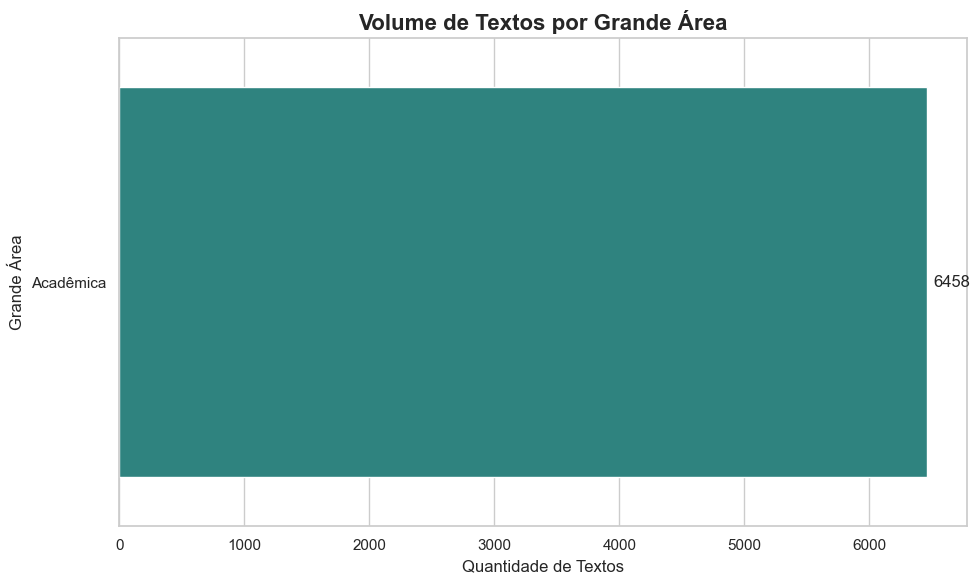

In [62]:
plt.figure(figsize=(10, 6))

# Ordenar por quantidade decrescente
ordem = df['broad_area'].value_counts().index
ax = sns.countplot(data=df, y='broad_area', order=ordem, palette='viridis')

plt.title('Volume de Textos por Grande Área', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Grande Área')

# Adiciona o número exato à frente de cada barra
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points')

plt.tight_layout()
plt.show()

C:\Users\Victor\AppData\Local\Temp\ipykernel_11128\3835821549.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='size_category', order=ordem_tamanho, palette='magma')


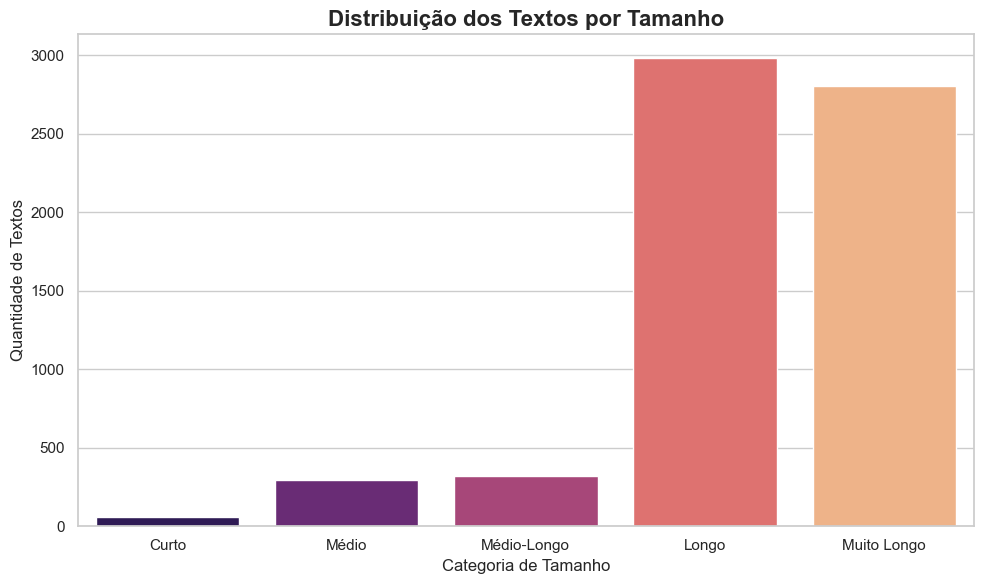

In [63]:
plt.figure(figsize=(10, 6))

# Define a ordem lógica das suas categorias
ordem_tamanho = ["Curto", "Médio", "Médio-Longo", "Longo", "Muito Longo"]

ax = sns.countplot(data=df, x='size_category', order=ordem_tamanho, palette='magma')

plt.title('Distribuição dos Textos por Tamanho', fontsize=16, fontweight='bold')
plt.xlabel('Categoria de Tamanho')
plt.ylabel('Quantidade de Textos')

plt.tight_layout()
plt.show()

C:\Users\Victor\AppData\Local\Temp\ipykernel_11128\161980344.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_temas.values, y=top_temas.index, palette='rocket')


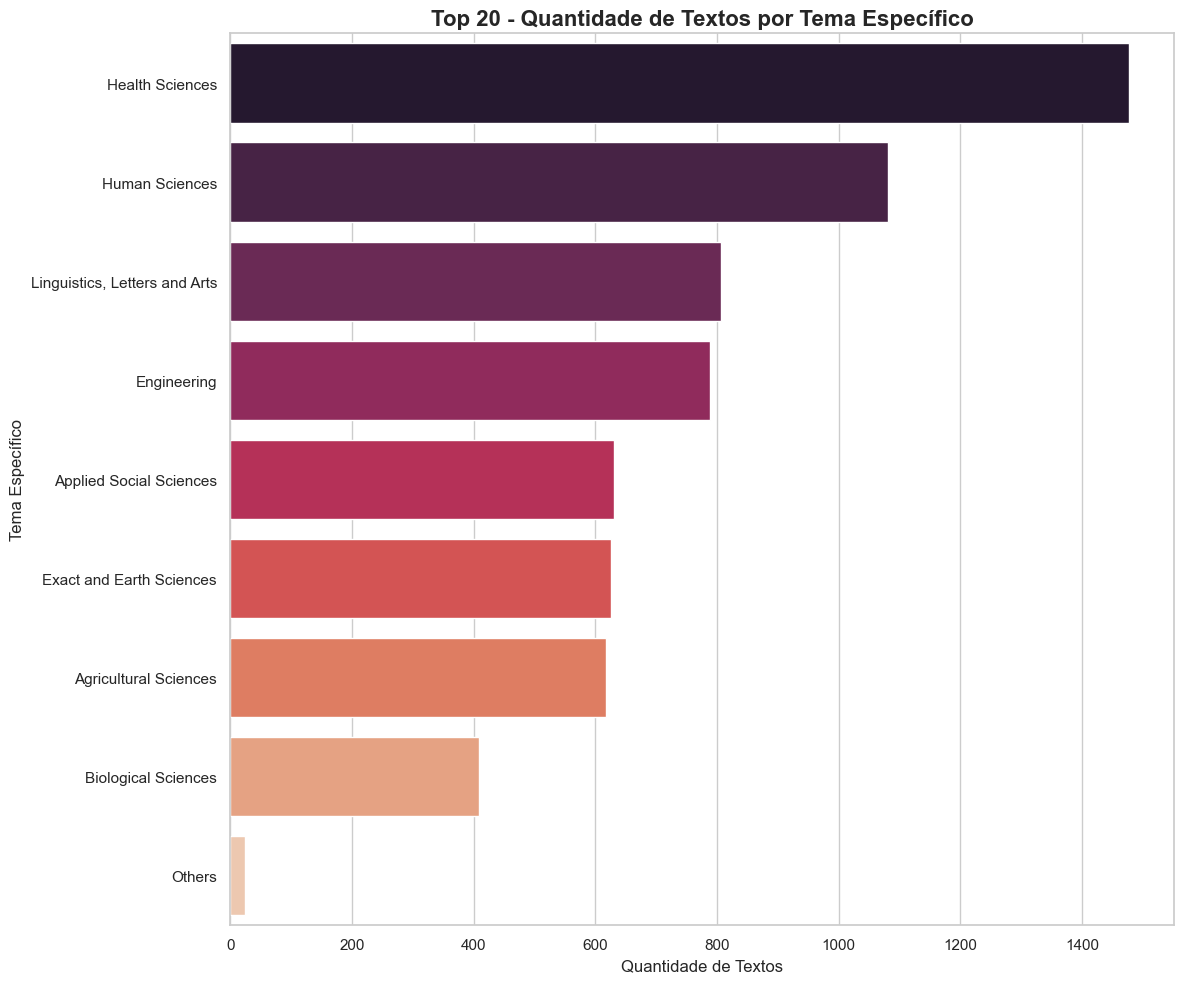

In [59]:
plt.figure(figsize=(12, 10))

# Pega apenas os 20 temas mais frequentes
top_temas = df['specific_theme'].value_counts().nlargest(20)

ax = sns.barplot(x=top_temas.values, y=top_temas.index, palette='rocket')

plt.title('Top 20 - Quantidade de Textos por Tema Específico', fontsize=16, fontweight='bold')
plt.xlabel('Quantidade de Textos')
plt.ylabel('Tema Específico')

plt.tight_layout()
plt.show()